https://github.com/liyipeng-moon/Triple-N

In [ ]:
import sys
sys.path.append("/n/home12/binxuwang/Github/NHP_NSD_analysis")
from data_loader import NSDDataLoader
import pandas as pd
import numpy as np
from os.path import join
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import numpy as np

In [1]:
NSD_root = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets/NSD_N3"

In [ ]:
NSD_root = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets/NSD_N3"
loader = NSDDataLoader(NSD_root)
fnlist = loader.list_files()
parsed_fnlist = [loader.parse_filename(fn) for fn in fnlist]
parsed_fnlist_df = pd.DataFrame(parsed_fnlist)
parsed_fnlist_df.head()

,file_type,date,monkey_name,group_number,full_filename,session_number,monkey_number,identifier
0,GoodUnit,240629,JianJian,2,GoodUnit_240629_JianJian_NSD1000_LOC_g2.mat,NaN,NaN,NaN
1,GoodUnit,240708,JianJian,2,GoodUnit_240708_JianJian_NSD1000_LOC_g2.mat,NaN,NaN,NaN
2,GoodUnit,240709,JianJian,2,GoodUnit_240709_JianJian_NSD1000_LOC_g2.mat,NaN,NaN,NaN
3,GoodUnit,240711,FaCai,4,GoodUnit_240711_FaCai_NSD1000_LOC_g4.mat,NaN,NaN,NaN
4,GoodUnit,240719,FaCai,3,GoodUnit_240719_FaCai_NSD1000_LOC_g3.mat,NaN,NaN,NaN


### Good Unit dataset

In [ ]:
h5_file = h5py.File(join(NSD_root, "GoodUnit_240709_JianJian_NSD1000_LOC_g2.mat"), "r")
print(h5_file.keys())

<KeysViewHDF5 ['#refs#', '#subsystem#', 'GoodUnitStrc', 'global_params', 'meta_data', 'trial_ML']>


```
=== Exploring GoodUnitStrc in GoodUnit_240629_JianJian_NSD1000_LOC_g2.mat ===

GoodUnitStrc structure:
KSidx: shape (456, 1), dtype object
Raster: shape (456, 1), dtype object
amplitudes: shape (456, 1), dtype object
qm: shape (456, 1), dtype object
response_matrix_img: shape (456, 1), dtype object
spikepos: shape (456, 1), dtype object
spiketime_ms: shape (456, 1), dtype object
unittype: shape (456, 1), dtype object
waveform: shape (456, 1), dtype object
waveformchan: shape (456, 1), dtype object

Key data summary:
  KSidx: shape (456, 1), dtype object
  Raster: shape (456, 1), dtype object
  amplitudes: shape (456, 1), dtype object
  qm: shape (456, 1), dtype object
  response_matrix_img: shape (456, 1), dtype object
  spikepos: shape (456, 1), dtype object
  spiketime_ms: shape (456, 1), dtype object
  unittype: shape (456, 1), dtype object
  waveform: shape (456, 1), dtype object
  waveformchan: shape (456, 1), dtype object

Extracted neural data keys: ['Raster', 'spiketime_ms', 'amplitudes', 'waveform', 'unittype']
```

In [80]:
parsed_fnlist_df

,file_type,date,monkey_name,group_number,full_filename,session_number,monkey_number,identifier
0,GoodUnit,240629,JianJian,2,GoodUnit_240629_JianJian_NSD1000_LOC_g2.mat,NaN,NaN,NaN
1,GoodUnit,240708,JianJian,2,GoodUnit_240708_JianJian_NSD1000_LOC_g2.mat,NaN,NaN,NaN
2,GoodUnit,240709,JianJian,2,GoodUnit_240709_JianJian_NSD1000_LOC_g2.mat,NaN,NaN,NaN
3,GoodUnit,240711,FaCai,4,GoodUnit_240711_FaCai_NSD1000_LOC_g4.mat,NaN,NaN,NaN
4,GoodUnit,240719,FaCai,3,GoodUnit_240719_FaCai_NSD1000_LOC_g3.mat,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
113,Processed,250122,NaN,NaN,Processed_ses55_250122_M3_7.mat,55,3,7
114,Processed,250126,NaN,NaN,Processed_ses56_250126_M5_6.mat,56,5,6
115,Processed,250126,NaN,NaN,Processed_ses57_250126_M3_2.mat,57,3,2
116,Processed,250224,NaN,NaN,Processed_ses58_250224_M3_1.mat,58,3,1


In [81]:
# Parse and explore the structure
def explore_h5_structure(dataset, group, name='', level=0, ):
    indent = "  " * level
    if isinstance(group, h5py.Group):
        print(f"{indent}{name}/ (Group)")
        for key in group.keys():
            if key not in ['#refs#', '#subsystem#']:
                explore_h5_structure(dataset, group[key], key, level + 1)
    elif isinstance(group, h5py.Dataset):
        print(f"{indent}{name}: shape {group.shape}, dtype {group.dtype}")
        if group.dtype == np.dtype('O'):
            # print(f"{indent}{name}: first element")
            explore_h5_structure(dataset, group[0,0], '(0,0)', level + 1)
    elif isinstance(group, h5py.Reference):
        print(f"{indent}{name}: Reference")
        explore_h5_structure(dataset, dataset[group], "value", level)


h5_file = h5py.File(join(NSD_root, "GoodUnit_240711_FaCai_NSD1000_LOC_g4.mat"), "r")
print("Top level keys:", list(h5_file.keys()))
explore_h5_structure(h5_file, h5_file)
# h5_file.close()

Top level keys: ['#refs#', '#subsystem#', 'GoodUnitStrc', 'global_params', 'meta_data', 'trial_ML']
/ (Group)
  GoodUnitStrc/ (Group)
    KSidx: shape (248, 1), dtype object
      (0,0): Reference
      value: shape (1, 1), dtype float64
    Raster: shape (248, 1), dtype object
      (0,0): Reference
      value: shape (450, 6308), dtype uint8
    amplitudes: shape (248, 1), dtype object
      (0,0): Reference
      value: shape (1, 85578), dtype float32
    qm: shape (248, 1), dtype object
      (0,0): Reference
      value: shape (1, 6), dtype uint32
    response_matrix_img: shape (248, 1), dtype object
      (0,0): Reference
      value: shape (450, 1072), dtype float32
    spikepos: shape (248, 1), dtype object
      (0,0): Reference
      value: shape (2, 1), dtype float32
    spiketime_ms: shape (248, 1), dtype object
      (0,0): Reference
      value: shape (1, 85578), dtype float64
    unittype: shape (248, 1), dtype object
      (0,0): Reference
      value: shape (1, 1), dty

In [45]:

# Get the actual data from GoodUnitStrc
if 'GoodUnitStrc' in h5_file:
    good_unit_strc = h5_file['GoodUnitStrc']
    print("\nGoodUnitStrc structure:")
    for key in good_unit_strc.keys():
        dataset = good_unit_strc[key]
        print(f"{key}: shape {dataset.shape}, dtype {dataset.dtype}")
        
    # Extract some sample data
    print("\nSample data exploration:")
    if 'Raster' in good_unit_strc:
        raster_refs = good_unit_strc['Raster'][:]
        print(f"Raster references shape: {raster_refs.shape}")
        
        # Access the first raster data
        if len(raster_refs) > 0:
            first_raster_ref = raster_refs[0, 0]
            first_raster_data = h5_file[first_raster_ref]
            print(f"First raster data shape: {first_raster_data.shape}")
            print(f"First raster data sample: {first_raster_data[:5] if len(first_raster_data) > 0 else 'Empty'}")


GoodUnitStrc structure:
KSidx: shape (675, 1), dtype object
Raster: shape (675, 1), dtype object
amplitudes: shape (675, 1), dtype object
qm: shape (675, 1), dtype object
response_matrix_img: shape (675, 1), dtype object
spikepos: shape (675, 1), dtype object
spiketime_ms: shape (675, 1), dtype object
unittype: shape (675, 1), dtype object
waveform: shape (675, 1), dtype object
waveformchan: shape (675, 1), dtype object

Sample data exploration:
Raster references shape: (675, 1)
First raster data shape: (450, 4308)
First raster data sample: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [98]:
h5_file = h5py.File(join(NSD_root, "GoodUnit_240629_JianJian_NSD1000_LOC_g2.mat"), "r")
explore_h5_structure(h5_file, h5_file['GoodUnitStrc'])

/ (Group)
  KSidx: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (1, 1), dtype float64
  Raster: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (450, 7434), dtype uint8
  amplitudes: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (1, 745), dtype float32
  qm: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (1, 6), dtype uint32
  response_matrix_img: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (450, 1072), dtype float32
  spikepos: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (2, 1), dtype float32
  spiketime_ms: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (1, 745), dtype float64
  unittype: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (1, 1), dtype float64
  waveform: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (61, 4), dtype float32
  waveformchan: shape (456, 1), dtype object
    (0,0): Referen

In [99]:
explore_h5_structure(h5_file, h5_file['meta_data'])

/ (Group)
  AIN: shape (2409281, 1), dtype float64
  DCode_IMEC/ (Group)
    CodeLoc: shape (2409, 1), dtype float64
    CodeTime: shape (2409, 1), dtype float64
    CodeVal: shape (2409, 1), dtype int16
  DCode_NI/ (Group)
    CodeLoc: shape (35236, 1), dtype float64
    CodeTime: shape (35236, 1), dtype float64
    CodeVal: shape (35236, 1), dtype int16
  IMEC_AP_META/ (Group)
    acqApLfSy: shape (3, 1), dtype float64
    appVersion: shape (1, 1), dtype float64
    fileCreateTime: shape (2,), dtype uint64
    fileName: shape (1, 1), dtype float64
    fileSHA1: shape (2,), dtype uint64
    fileSizeBytes: shape (1, 1), dtype float64
    fileTimeSecs: shape (1, 1), dtype float64
    firstSample: shape (1, 1), dtype float64
    gateMode: shape (9, 1), dtype uint16
    imAiRangeMax: shape (1, 1), dtype float64
    imAiRangeMin: shape (1, 1), dtype float64
    imAnyChanFullBand: shape (1, 1), dtype uint8
    imCalibrated: shape (1, 1), dtype uint8
    imChan0apGain: shape (1, 1), dtype fl

In [106]:
h5_file['meta_data']["onset_time_ms"][:]

array([[  56345.],
       [  56637.],
       [  56937.],
       ...,
       [2401859.],
       [2402159.],
       [2402459.]])

In [110]:
exp_subject = "".join([chr(x) for x in h5_file['meta_data']["exp_subject"][:].flatten()])
print(exp_subject)

JianJian


In [112]:
np.unique(h5_file['meta_data']["trial_valid_idx"][:].astype(int))

array([   0,    1,    2, ..., 1070, 1071, 1072])

In [101]:
h5_file['meta_data']["dataset_valid_idx"][:].sum()

7434.0

In [123]:
def concat_ref_dataset(h5_file, ref_array):
    ref_array_shape = ref_array.shape
    assert ref_array.dtype == np.dtype('O')
    concat_data = []
    for i in range(ref_array_shape[0]):
        for j in range(ref_array_shape[1]):
            ref = ref_array[i,j]
            ref_data = h5_file[ref][:]
            concat_data.append(ref_data)
    concat_data = np.stack(concat_data, axis=0)
    entry_shape = concat_data.shape[1:]
    return concat_data.reshape(*ref_array_shape, *entry_shape)

In [ ]:
explore_h5_structure(h5_file, h5_file['GoodUnitStrc'])

/ (Group)
  KSidx: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (1, 1), dtype float64
  Raster: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (450, 7434), dtype uint8
  amplitudes: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (1, 745), dtype float32
  qm: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (1, 6), dtype uint32
  response_matrix_img: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (450, 1072), dtype float32
  spikepos: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (2, 1), dtype float32
  spiketime_ms: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (1, 745), dtype float64
  unittype: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (1, 1), dtype float64
  waveform: shape (456, 1), dtype object
    (0,0): Reference
    value: shape (61, 4), dtype float32
  waveformchan: shape (456, 1), dtype object
    (0,0): Referen

### Loading all relevant info

In [ ]:
exp_subject = "".join([chr(x) for x in h5_file['meta_data']["exp_subject"][:].flatten()])
trial_valid_idx = h5_file['meta_data']["trial_valid_idx"][:].astype(int)
dataset_valid_idx = h5_file['meta_data']["dataset_valid_idx"][:].astype(bool)
Raster = concat_ref_dataset(h5_file, h5_file['GoodUnitStrc']['Raster']).squeeze() # (n_units, n_timepoints, n_trials)
response_matrix_img = concat_ref_dataset(h5_file, h5_file['GoodUnitStrc']['response_matrix_img']).squeeze() # (n_units, n_timepoints, n_images[average])
unittype = concat_ref_dataset(h5_file, h5_file['GoodUnitStrc']['unittype']).squeeze() # (n_units, )
KSidx = concat_ref_dataset(h5_file, h5_file['GoodUnitStrc']['KSidx']).squeeze() # (n_units, )
spikepos = concat_ref_dataset(h5_file, h5_file['GoodUnitStrc']['spikepos']).squeeze() # (n_units, )
# check the shape matches
n_units = Raster.shape[0]
n_timepoints = Raster.shape[1]
n_valid_trials = Raster.shape[2]
n_images = response_matrix_img.shape[2]
assert (dataset_valid_idx.sum() == n_valid_trials)
assert (len(np.unique(trial_valid_idx)) == n_images+1)
assert (trial_valid_idx[~dataset_valid_idx] == 0).all()
assert (len(np.unique(trial_valid_idx[dataset_valid_idx])) == n_images)
assert len(unittype) == n_units
assert len(KSidx) == n_units
assert len(spikepos) == n_units
# the following may fail. 
# spiketime_ms = concat_ref_dataset(h5_file, h5_file['GoodUnitStrc']['spiketime_ms']).squeeze()
# waveform = concat_ref_dataset(h5_file, h5_file['GoodUnitStrc']['waveform']).squeeze()
# waveformchan = concat_ref_dataset(h5_file, h5_file['GoodUnitStrc']['waveformchan']).squeeze()

### From raster to average PSTH

In [154]:
Raster[:,:, trial_valid_idx[dataset_valid_idx] == 5].astype(float).mean(axis=-1).shape

(456, 450)

In [153]:
response_matrix_img[:,:,0].shape

(456, 450)

In [166]:
img_psth_all = []
for img_idx in range(1,n_images+1):
    img_psth = Raster[:,:, trial_valid_idx[dataset_valid_idx] == img_idx].astype(np.float32).mean(axis=-1)
    img_psth_all.append(img_psth)
img_psth_all = np.stack(img_psth_all, axis=-1)

In [ ]:
kernel = np.ones(21) / 21 * 1000
img_psth_all_filtered = ndimage.convolve1d(img_psth_all, kernel, axis=1, mode='constant')

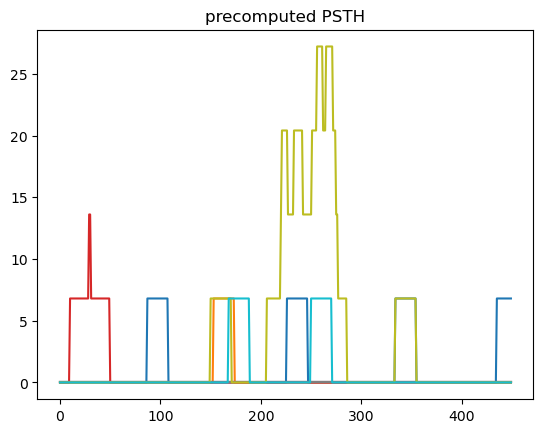

In [190]:
plt.plot(response_matrix_img[6,:,:10])
plt.title("precomputed PSTH")
plt.show()

In [191]:
response_matrix_img[:,:,:].mean() / img_psth_all_filtered[:,:,:].mean()

1.0117474

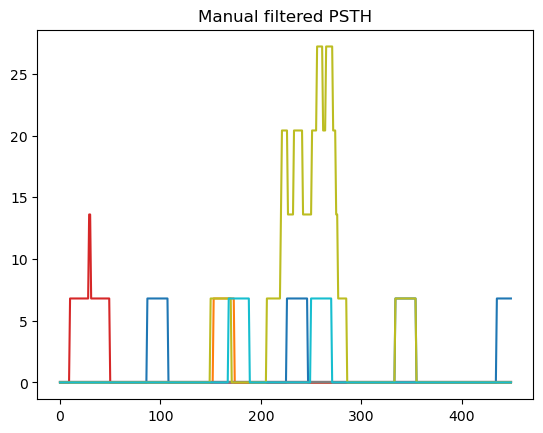

In [192]:
plt.plot(img_psth_all_filtered[6,:,:10])
plt.title("Manual filtered PSTH")
plt.show()

In [ ]:
(trial_valid_idx[dataset_valid_idx] == 5).sum()

7

In [ ]:
response_matrix_img.shape

(456, 450, 1072)

### Scratch

In [129]:
Raster.shape

(456, 450, 7434)

In [121]:
KSidx

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        36.,  37.,  38.,  39.,  40.,  41.,  43.,  44.,  45.,  46.,  47.,
        48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  59.,
        60.,  62.,  63.,  64.,  65.,  66.,  67.,  68.,  69.,  70.,  71.,
        72.,  73.,  74.,  75.,  76.,  77.,  78.,  80.,  81.,  82.,  83.,
        84.,  85.,  86.,  87.,  88.,  89.,  90.,  91.,  92.,  93.,  94.,
        95.,  97.,  98.,  99., 100., 101., 102., 103., 104., 105., 106.,
       107., 108., 109., 110., 111., 112., 113., 114., 115., 116., 117.,
       118., 119., 120., 121., 122., 123., 124., 125., 126., 127., 128.,
       129., 130., 131., 132., 133., 134., 135., 136., 137., 138., 139.,
       140., 142., 143., 144., 145., 146., 147., 148., 149., 150., 151.,
       152., 153., 154., 155., 156., 157., 158., 15

In [114]:
h5_file['GoodUnitStrc']['unittype']

<HDF5 dataset "unittype": shape (456, 1), type "|O">

In [105]:
h5_file[h5_file['GoodUnitStrc']['response_matrix_img'][0,0]][:]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

### Visualzie

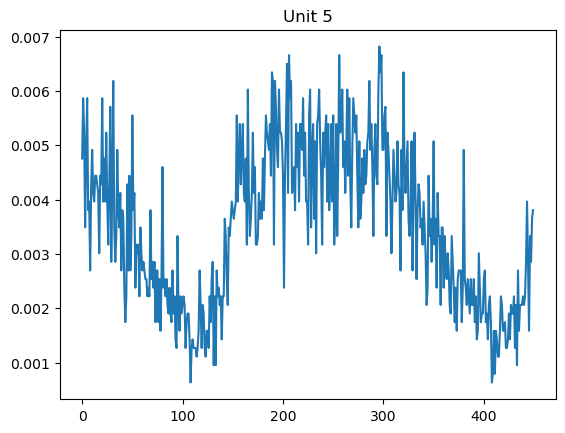

In [93]:
unit_idx = 5
ref = h5_file['GoodUnitStrc']['Raster'][unit_idx,0]
raster_0 = h5_file[ref][:]
plt.plot(raster_0.mean(axis=1))
plt.title(f"Unit {unit_idx}")
plt.show()


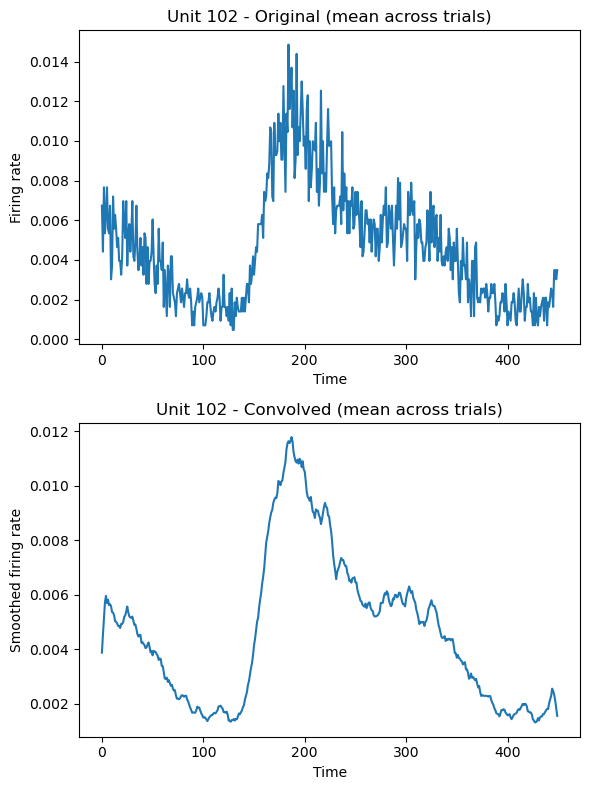

In [69]:

# Convolve raster_0 along the 1st dimension (time axis)
from scipy import ndimage
import numpy as np

# Create a simple Gaussian kernel for smoothing
kernel_size = 10
sigma = 5
x = np.arange(kernel_size) - (kernel_size - 1) / 2
kernel = np.exp(-x**2 / (2 * sigma**2))
kernel = kernel / kernel.sum()  # Normalize
# Convolve along axis 1 (time dimension)
raster_0_convolved = ndimage.convolve1d(raster_0.astype(np.float32), kernel, axis=0, mode='constant')

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# Original
ax1.plot(raster_0.mean(axis=1))
ax1.set_title(f"Unit {unit_idx} - Original (mean across trials)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Firing rate")

# Convolved
ax2.plot(raster_0_convolved.mean(axis=1))
ax2.set_title(f"Unit {unit_idx} - Convolved (mean across trials)")
ax2.set_xlabel("Time")
ax2.set_ylabel("Smoothed firing rate")

plt.tight_layout()
plt.show()

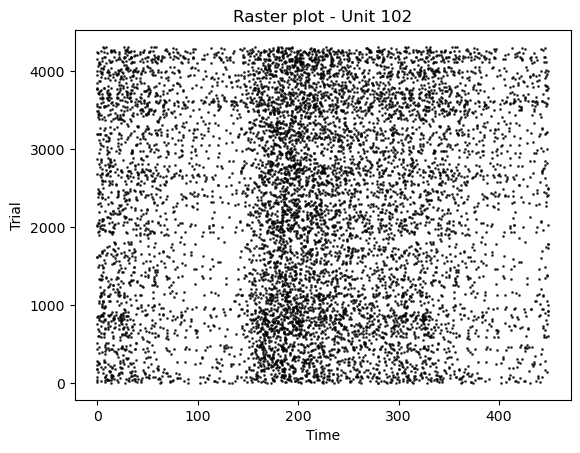

In [ ]:
# plot the raster as raster plot

# Create scatter plot from raster data
trial_indices, time_indices = np.where(raster_0.T > 0)
plt.scatter(time_indices, trial_indices, s=1, c='black', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Trial')
plt.title(f'Raster plot - Unit {unit_idx}')
plt.show()

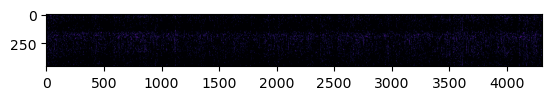

In [ ]:
# Create a simple Gaussian kernel for smoothing
kernel_size = 10
sigma = 5
x = np.arange(kernel_size) - (kernel_size - 1) / 2
kernel = np.exp(-x**2 / (2 * sigma**2))
kernel = kernel / kernel.sum()  # Normalize
# Convolve along axis 1 (time dimension)
raster_0_convolved = ndimage.convolve1d(raster_0.astype(np.float32), kernel, axis=0, mode='constant')
plt.imshow(raster_0_convolved, cmap="inferno")
plt.show()

In [36]:
isinstance(h5_file['GoodUnitStrc']["Raster"], h5py.Dataset)

True

In [31]:
import numpy as np
h5_file['GoodUnitStrc']["Raster"].dtype == np.dtype('O')

True

### Failed attempts mat73, scipy

In [ ]:
import scipy.io
mat_file = scipy.io.loadmat(join(NSD_root, "GoodUnit_240709_JianJian_NSD1000_LOC_g2.mat"))

print(mat_file.keys())

NotImplementedError: Please use HDF reader for matlab v7.3 files, e.g. h5py

In [ ]:
import mat73
mat_file = mat73.loadmat(join(NSD_root, "GoodUnit_240709_JianJian_NSD1000_LOC_g2.mat"))
print(mat_file.keys())

ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB

KeyboardInterrupt: 

## Processed file

In [13]:
parsed_fnlist_df.tail(10)

,file_type,date,monkey_name,group_number,full_filename,session_number,monkey_number,identifier
108,Processed,241119,NaN,NaN,Processed_ses50_241119_M3_2.mat,50,3,2
109,Processed,241210,NaN,NaN,Processed_ses51_241210_M1_3.mat,51,1,3
110,Processed,241210,NaN,NaN,Processed_ses52_241210_M3_1.mat,52,3,1
111,Processed,241212,NaN,NaN,Processed_ses53_241212_M1_1.mat,53,1,1
112,Processed,250122,NaN,NaN,Processed_ses54_250122_M5_6.mat,54,5,6
113,Processed,250122,NaN,NaN,Processed_ses55_250122_M3_7.mat,55,3,7
114,Processed,250126,NaN,NaN,Processed_ses56_250126_M5_6.mat,56,5,6
115,Processed,250126,NaN,NaN,Processed_ses57_250126_M3_2.mat,57,3,2
116,Processed,250224,NaN,NaN,Processed_ses58_250224_M3_1.mat,58,3,1
117,Processed,250228,NaN,NaN,Processed_ses59_250228_M3_1.mat,59,3,1


In [ ]:
import scipy.io
mat_file = scipy.io.loadmat(join(NSD_root, "Processed_ses59_250228_M3_1.mat"))
print(mat_file.keys())
for k in mat_file:
    print(k, type(mat_file[k]), end=" ")
    try:
        print(mat_file[k].shape)
    except:
        pass

dict_keys(['__header__', '__version__', '__globals__', 'B_SI', 'F_SI', 'O_SI', 'UnitNum', 'UnitType', 'best_r_time1', 'best_r_time2', 'mean_psth', 'pos', 'r_search_pool', 'reliability_basic', 'reliability_best', 'reliability_find_testset', 'response_basic', 'response_best', 'snr', 'snrmax'])
__header__ <class 'bytes'> __version__ <class 'str'> __globals__ <class 'list'> B_SI <class 'numpy.ndarray'> (1, 389)
F_SI <class 'numpy.ndarray'> (1, 389)
O_SI <class 'numpy.ndarray'> (1, 389)
UnitNum <class 'numpy.ndarray'> (1, 1)
UnitType <class 'numpy.ndarray'> (1, 389)
best_r_time1 <class 'numpy.ndarray'> (1, 389)
best_r_time2 <class 'numpy.ndarray'> (1, 389)
mean_psth <class 'numpy.ndarray'> (389, 450)
pos <class 'numpy.ndarray'> (1, 389)
r_search_pool <class 'numpy.ndarray'> (389, 589)
reliability_basic <class 'numpy.ndarray'> (1, 389)
reliability_best <class 'numpy.ndarray'> (1, 389)
reliability_find_testset <class 'numpy.ndarray'> (1, 389)
response_basic <class 'numpy.ndarray'> (389, 1072)